In [1]:
from gbp.gbp import *
from utils.graphs import *

In [2]:
def make_graph_with_loop_spans(
    N=200,
    layout="line",          # "line" | "circle" | "random_walk"
    step=1.0,
    loop_spans_small=(3, 10),
    loop_spans_large=(60, 160),
    n_small=0,
    n_large=0,
    prior_prop=0.0,         # NEW: fraction of nodes (excluding 0) connected to "prior"
    seed=0,
):
    rng = np.random.default_rng(seed)

    def wrap_angle(a):
        return np.arctan2(np.sin(a), np.cos(a))

    def relpose_SE2(pose_i, pose_j):
        """z_ij = [dx_local, dy_local, dtheta], local frame is i"""
        xi, yi, thi = pose_i
        xj, yj, thj = pose_j
        Ri = np.array([[np.cos(thi), -np.sin(thi)],
                       [np.sin(thi),  np.cos(thi)]], dtype=float)
        dp = np.array([xj - xi, yj - yi], dtype=float)
        trans_local = Ri.T @ dp
        dth = wrap_angle(thj - thi)
        return np.array([trans_local[0], trans_local[1], dth], dtype=float)

    # --------- poses (GT) ----------
    poses = []
    if layout == "line":
        x = 0.0; y = 0.0; th = 0.0
        poses.append((x, y, th))
        for _ in range(1, N):
            x += step
            poses.append((x, y, th))

    elif layout == "circle":
        R = step * N / (2*np.pi)
        ang = np.linspace(0, 2*np.pi, N, endpoint=False)
        for a in ang:
            x = R * np.cos(a)
            y = R * np.sin(a)
            th = wrap_angle(a + np.pi/2)
            poses.append((float(x), float(y), float(th)))

    elif layout == "random_walk":
        x = 0.0; y = 0.0; th = 0.0
        poses.append((x, y, th))
        for _ in range(1, N):
            dth = rng.normal(0.0, 0.2)
            th = wrap_angle(th + dth)
            x += step * np.cos(th)
            y += step * np.sin(th)
            poses.append((float(x), float(y), float(th)))
    else:
        raise ValueError("layout must be line/circle/random_walk")

    # --------- nodes ----------
    nodes = []
    for i, (px, py, pth) in enumerate(poses):
        nodes.append({
            "data": {"id": f"{i}", "layer": 0, "dim": 3, "theta": float(pth), "num_base": 1},
            "position": {"x": float(px), "y": float(py)}
        })

    edges = []

    # --------- odom chain edges (binary, with z) ----------
    for i in range(N - 1):
        z_ij = relpose_SE2(poses[i], poses[i+1])
        edges.append({"data": {"source": f"{i}", "target": f"{i+1}", "kind": "odom", "z": z_ij.tolist()}})
    
    """
    if layout == "circle":
        z_ij = relpose_SE2(poses[N-1], poses[0])
        edges.append({"data": {"source": f"{N-1}", "target": f"0", "kind": "odom", "z": z_ij.tolist()}})
    """
    
    # --------- loop edges with controlled spans (binary, with z) ----------
    def add_loops(n_add, span_lo, span_hi, kind="loop"):
        if n_add <= 0:
            return
        span_lo = int(span_lo); span_hi = int(span_hi)
        assert 1 <= span_lo <= span_hi

        added = set()
        max_try = 50 * n_add
        t = 0
        while len(added) < n_add and t < max_try:
            t += 1
            span = int(rng.integers(span_lo, span_hi + 1))
            i = int(rng.integers(0, N - span))
            j = i + span
            key = (i, j)
            if key in added:
                continue
            added.add(key)
            z_ij = relpose_SE2(poses[i], poses[j])
            edges.append({"data": {"source": f"{i}", "target": f"{j}", "kind": kind, "z": z_ij.tolist()}})

    add_loops(n_small, loop_spans_small[0], loop_spans_small[1], kind="loop")
    add_loops(n_large, loop_spans_large[0], loop_spans_large[1], kind="loop")

    # --------- priors: connect some nodes to virtual "prior" ----------
    if prior_prop <= 0.0:
        strong_ids = set()
    elif prior_prop >= 1.0:
        strong_ids = set(range(1, N))   # exclude 0 (already anchored strongly in build_noisy_pose_graph)
    else:
        k = int(np.floor(float(prior_prop) * N))
        k = max(0, min(k, N - 1))
        strong_ids = set(rng.choice(np.arange(1, N), size=k, replace=False).tolist())

    for i in strong_ids:
        edges.append({"data": {"source": f"{i}", "target": "prior", "kind": "prior"}})

    return nodes, edges


1033
before iteration   loss:  133621468.03498995  SE:  53639508.99337417


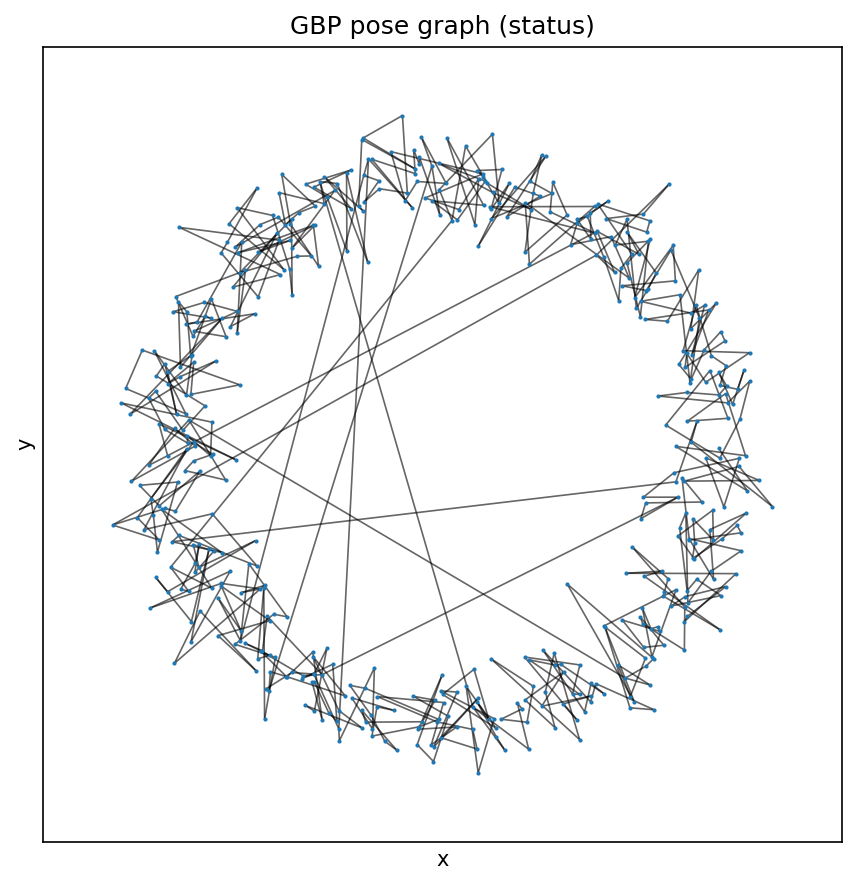

133621468.03498995


In [3]:
from IPython.display import clear_output

N=512
step=25
prob=0.05
radius=50 
prior_prop=1
prior_sigma=200
odom_sigma=1
loop_sigma=1
seed = 2001


nodes, edges = make_slam_like_graph(N, step, prob, radius, prior_prop, seed=seed)
nodes, edges = make_graph_with_loop_spans(N=N, step=25, layout="circle", loop_spans_small=(3, 10), 
            loop_spans_large=(int(N//3), int(N//2)), n_small=0, n_large=10, prior_prop=prior_prop, seed=seed)

# construct GBP graph
gbp_graph = build_noisy_pose_graph(nodes, edges, prior_sigma=prior_sigma, odom_sigma=odom_sigma, 
            loop_sigma=loop_sigma, seed=seed)
gbp_graph.min_linear_iters = 1
gbp_graph.eta_damping = 0
gbp_graph.num_undamped_iters = 1

threshold = 1e-3
prev_loss = 1e10
counter = 0
print(gbp_graph.n_factor_nodes)
loss = gbp_graph.loss()
print("before iteration ", " loss: ", loss, " SE: ", gbp_graph.SE())  


plot_gbp_graph_xy(gbp_graph, edges, use="status", s=1, figsize=(8, 6), dpi=150)
print(gbp_graph.loss())

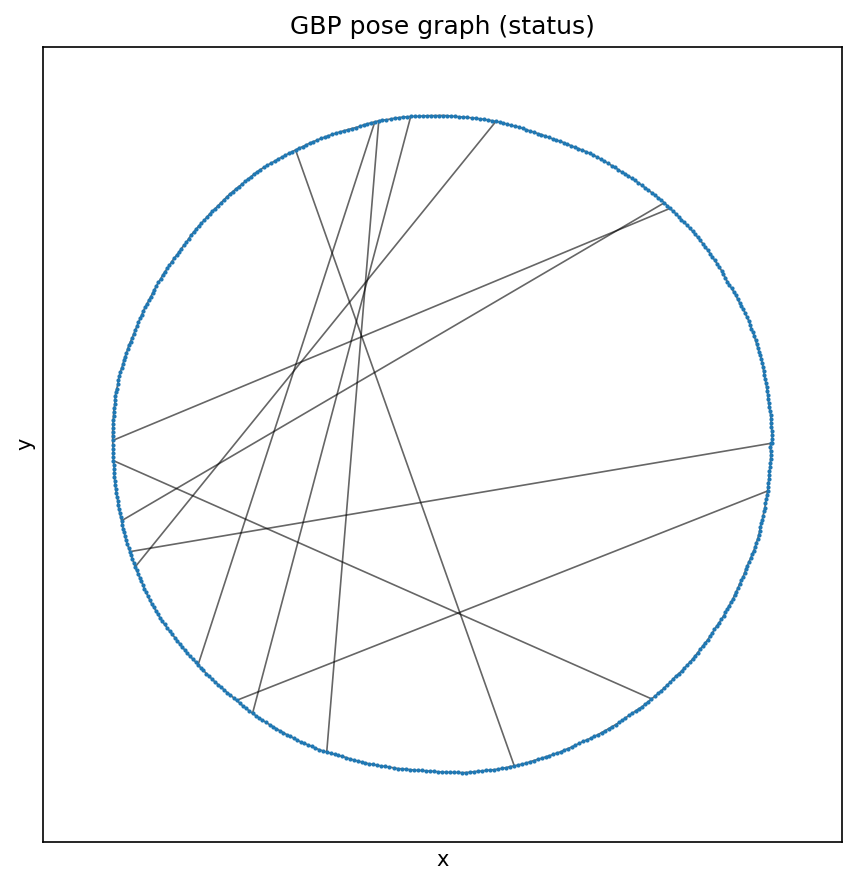

after iteration  1000  loss:  872.1033456411287  SE:  328558.2417324713


In [5]:
for iter in range(1000):
    """
    for i in range(gbp_graph.n_var_nodes):
        for factor in gbp_graph.var_nodes[i].adj_factors:
            factor.compute_messages()
    
        gbp_graph.var_nodes[i].update_belief()

    
    for j in range(gbp_graph.n_var_nodes):
        i = gbp_graph.n_var_nodes - j - 1
        for factor in gbp_graph.var_nodes[i].adj_factors:
            factor.compute_messages()
        gbp_graph.var_nodes[i].update_belief() 
    """

    gbp_graph.synchronous_iteration()
    

    if iter % 1 == 0:
        clear_output(wait=True)
        plot_gbp_graph_xy(gbp_graph, edges, use="status", s=1, figsize=(8, 6), dpi=150)

    loss = gbp_graph.loss()
    if abs(prev_loss - loss) < threshold:
        counter += 1
    else:
        counter = 0
    print("after iteration ", iter+1, " loss: ", loss, " SE: ", gbp_graph.SE())   
    prev_loss = loss

    if counter >= 3:
        print("Converged after iteration ", iter+1)
        break

    #gbp_graph.relinearise_factors()



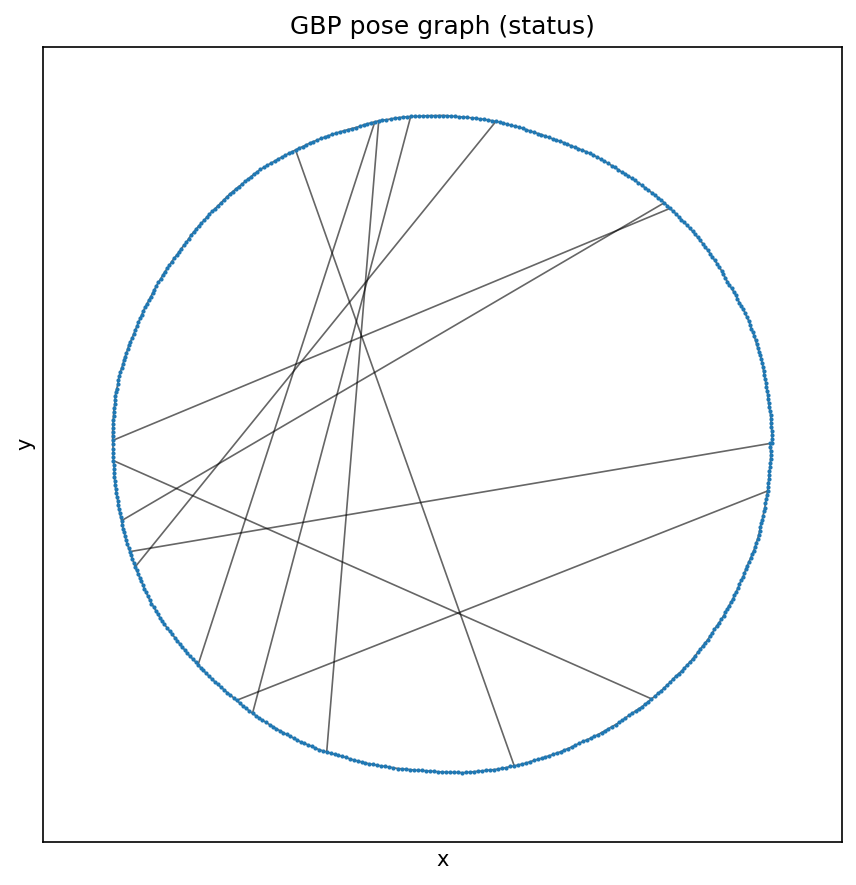

after iteration  33  loss:  860.0156873799987  SE:  326276.7058862219
Converged after iteration  33


In [ ]:


for iter in range(1000):
    for i in range(gbp_graph.n_var_nodes):
        for factor in gbp_graph.var_nodes[i].adj_factors:
            factor.compute_messages()
    
        gbp_graph.var_nodes[i].update_belief()

    
    for j in range(gbp_graph.n_var_nodes):
        i = gbp_graph.n_var_nodes - j - 1
        for factor in gbp_graph.var_nodes[i].adj_factors:
            factor.compute_messages()
        gbp_graph.var_nodes[i].update_belief() 


    #gbp_graph.synchronous_iteration()
    

    if iter % 1 == 1:
        clear_output(wait=True)
        plot_gbp_graph_xy(gbp_graph, edges, use="status", s=1, figsize=(8, 6), dpi=150)

    loss = gbp_graph.loss()
    if abs(prev_loss - loss) < threshold:
        counter += 1
    else:
        counter = 0
    print("after iteration ", iter+1, " loss: ", loss, " SE: ", gbp_graph.SE())   
    prev_loss = loss

    if counter >= 3:
        print("Converged after iteration ", iter+1)
        break

    gbp_graph.relinearise_factors()





In [59]:
print(gbp_graph.factors[1].measurement.translation()[0], gbp_graph.factors[1].measurement.translation()[1], gbp_graph.factors[1].measurement.angle())
print(gbp_graph.var_nodes[1].status.translation()[0], gbp_graph.var_nodes[1].status.translation()[1], gbp_graph.var_nodes[1].status.angle())

25.205697323735997 -1.0716306975494634 0.029800624389957425
2038.1922515205679 25.321039065106365 1.6036317712712829


In [60]:
a = gbp_graph.var_nodes[0].status * gbp_graph.factors[1].measurement
print(a.translation()[0], a.translation()[1], a.angle())

2038.2549021303726 25.205697442512374 1.600596954389947


In [61]:
print(gbp_graph.var_nodes[1].status.translation()[0], gbp_graph.var_nodes[1].status.translation()[1], gbp_graph.var_nodes[1].status.angle())

2038.1922515205679 25.321039065106365 1.6036317712712829


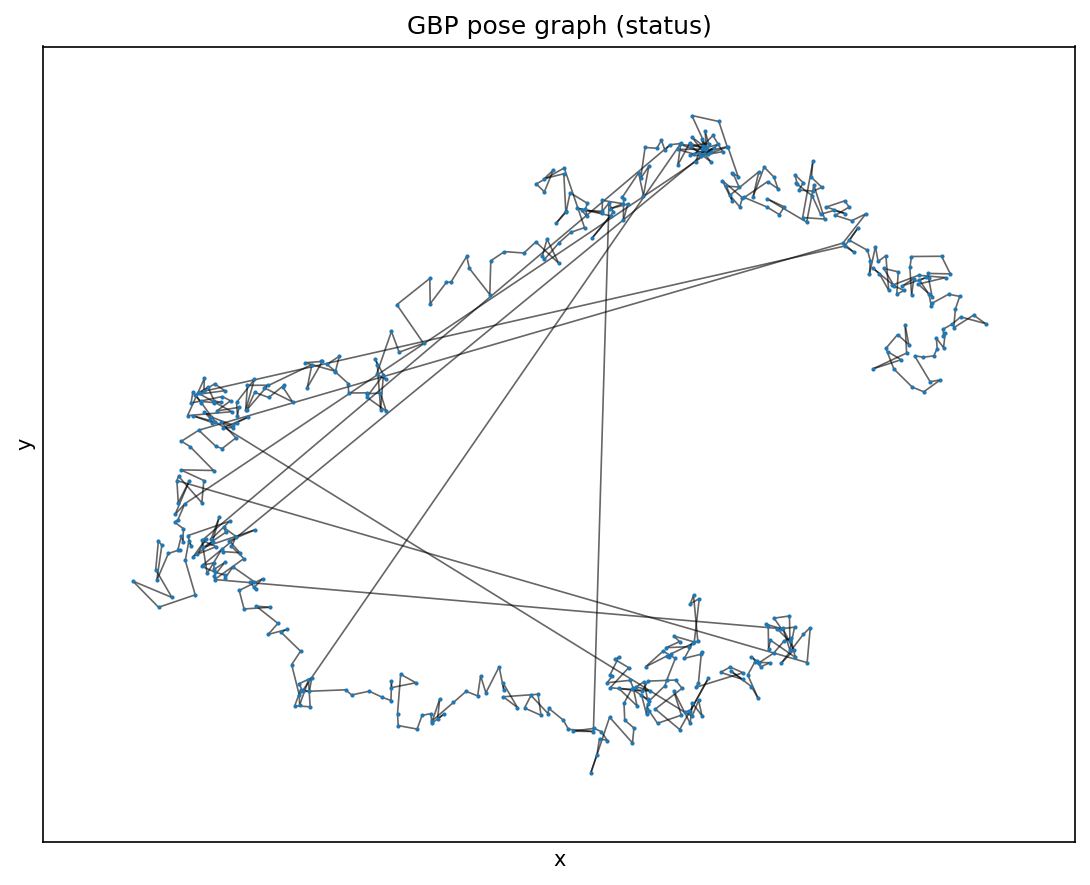

KeyboardInterrupt: 

In [7]:
# construct GBP graph
gbp_graph2 = build_noisy_pose_graph(nodes, edges, prior_sigma=prior_sigma, odom_sigma=odom_sigma, 
            loop_sigma=loop_sigma, seed=seed)

prev_loss = 1e10
threshold = 1e-4
counter = 0

loss = gbp_graph2.loss()
print("before iteration ", " loss: ", loss, " SE: ", gbp_graph2.SE())  

for j in range(500):
    clear_output(wait=True)
    plot_gbp_graph_xy(gbp_graph2, edges, use="status", s=1, figsize=(8, 6), dpi=150)

    mu, Sigma = gbp_graph2.joint_distribution_cov()

    for i, v in enumerate(gbp_graph2.var_nodes):
        a = 0.1
        gbp_graph2.var_nodes[i].status += a*m.SE2Tangent(mu[3*i], mu[3*i+1], mu[3*i+2])

    for f in gbp_graph2.factors:
        f.linpoints = [vn.status for vn in f.adj_var_nodes]
        f.update_factor()

    loss = gbp_graph2.loss()
    print("after iteration ", j+1, " loss: ", loss, " SE: ", gbp_graph2.SE())   

    if abs(prev_loss - loss) < threshold:
        counter += 1
    else:
        counter = 0

    if counter >= 3:
        print("Converged after iteration ", j+1)
        break   
    prev_loss = loss

In [6]:
SE1 = 0
SE2 = 0
for i in range(gbp_graph.n_var_nodes):
    SE1 += (gbp_graph.var_nodes[i].status - gbp_graph.var_nodes[i].GT).weightedNorm()
    SE2 += (gbp_graph2.var_nodes[i].status - gbp_graph2.var_nodes[i].GT).weightedNorm()
print("SE1: ", SE1)
print("SE2: ", SE2)



SE1:  2550.7011523621413
SE2:  2567.876806937521


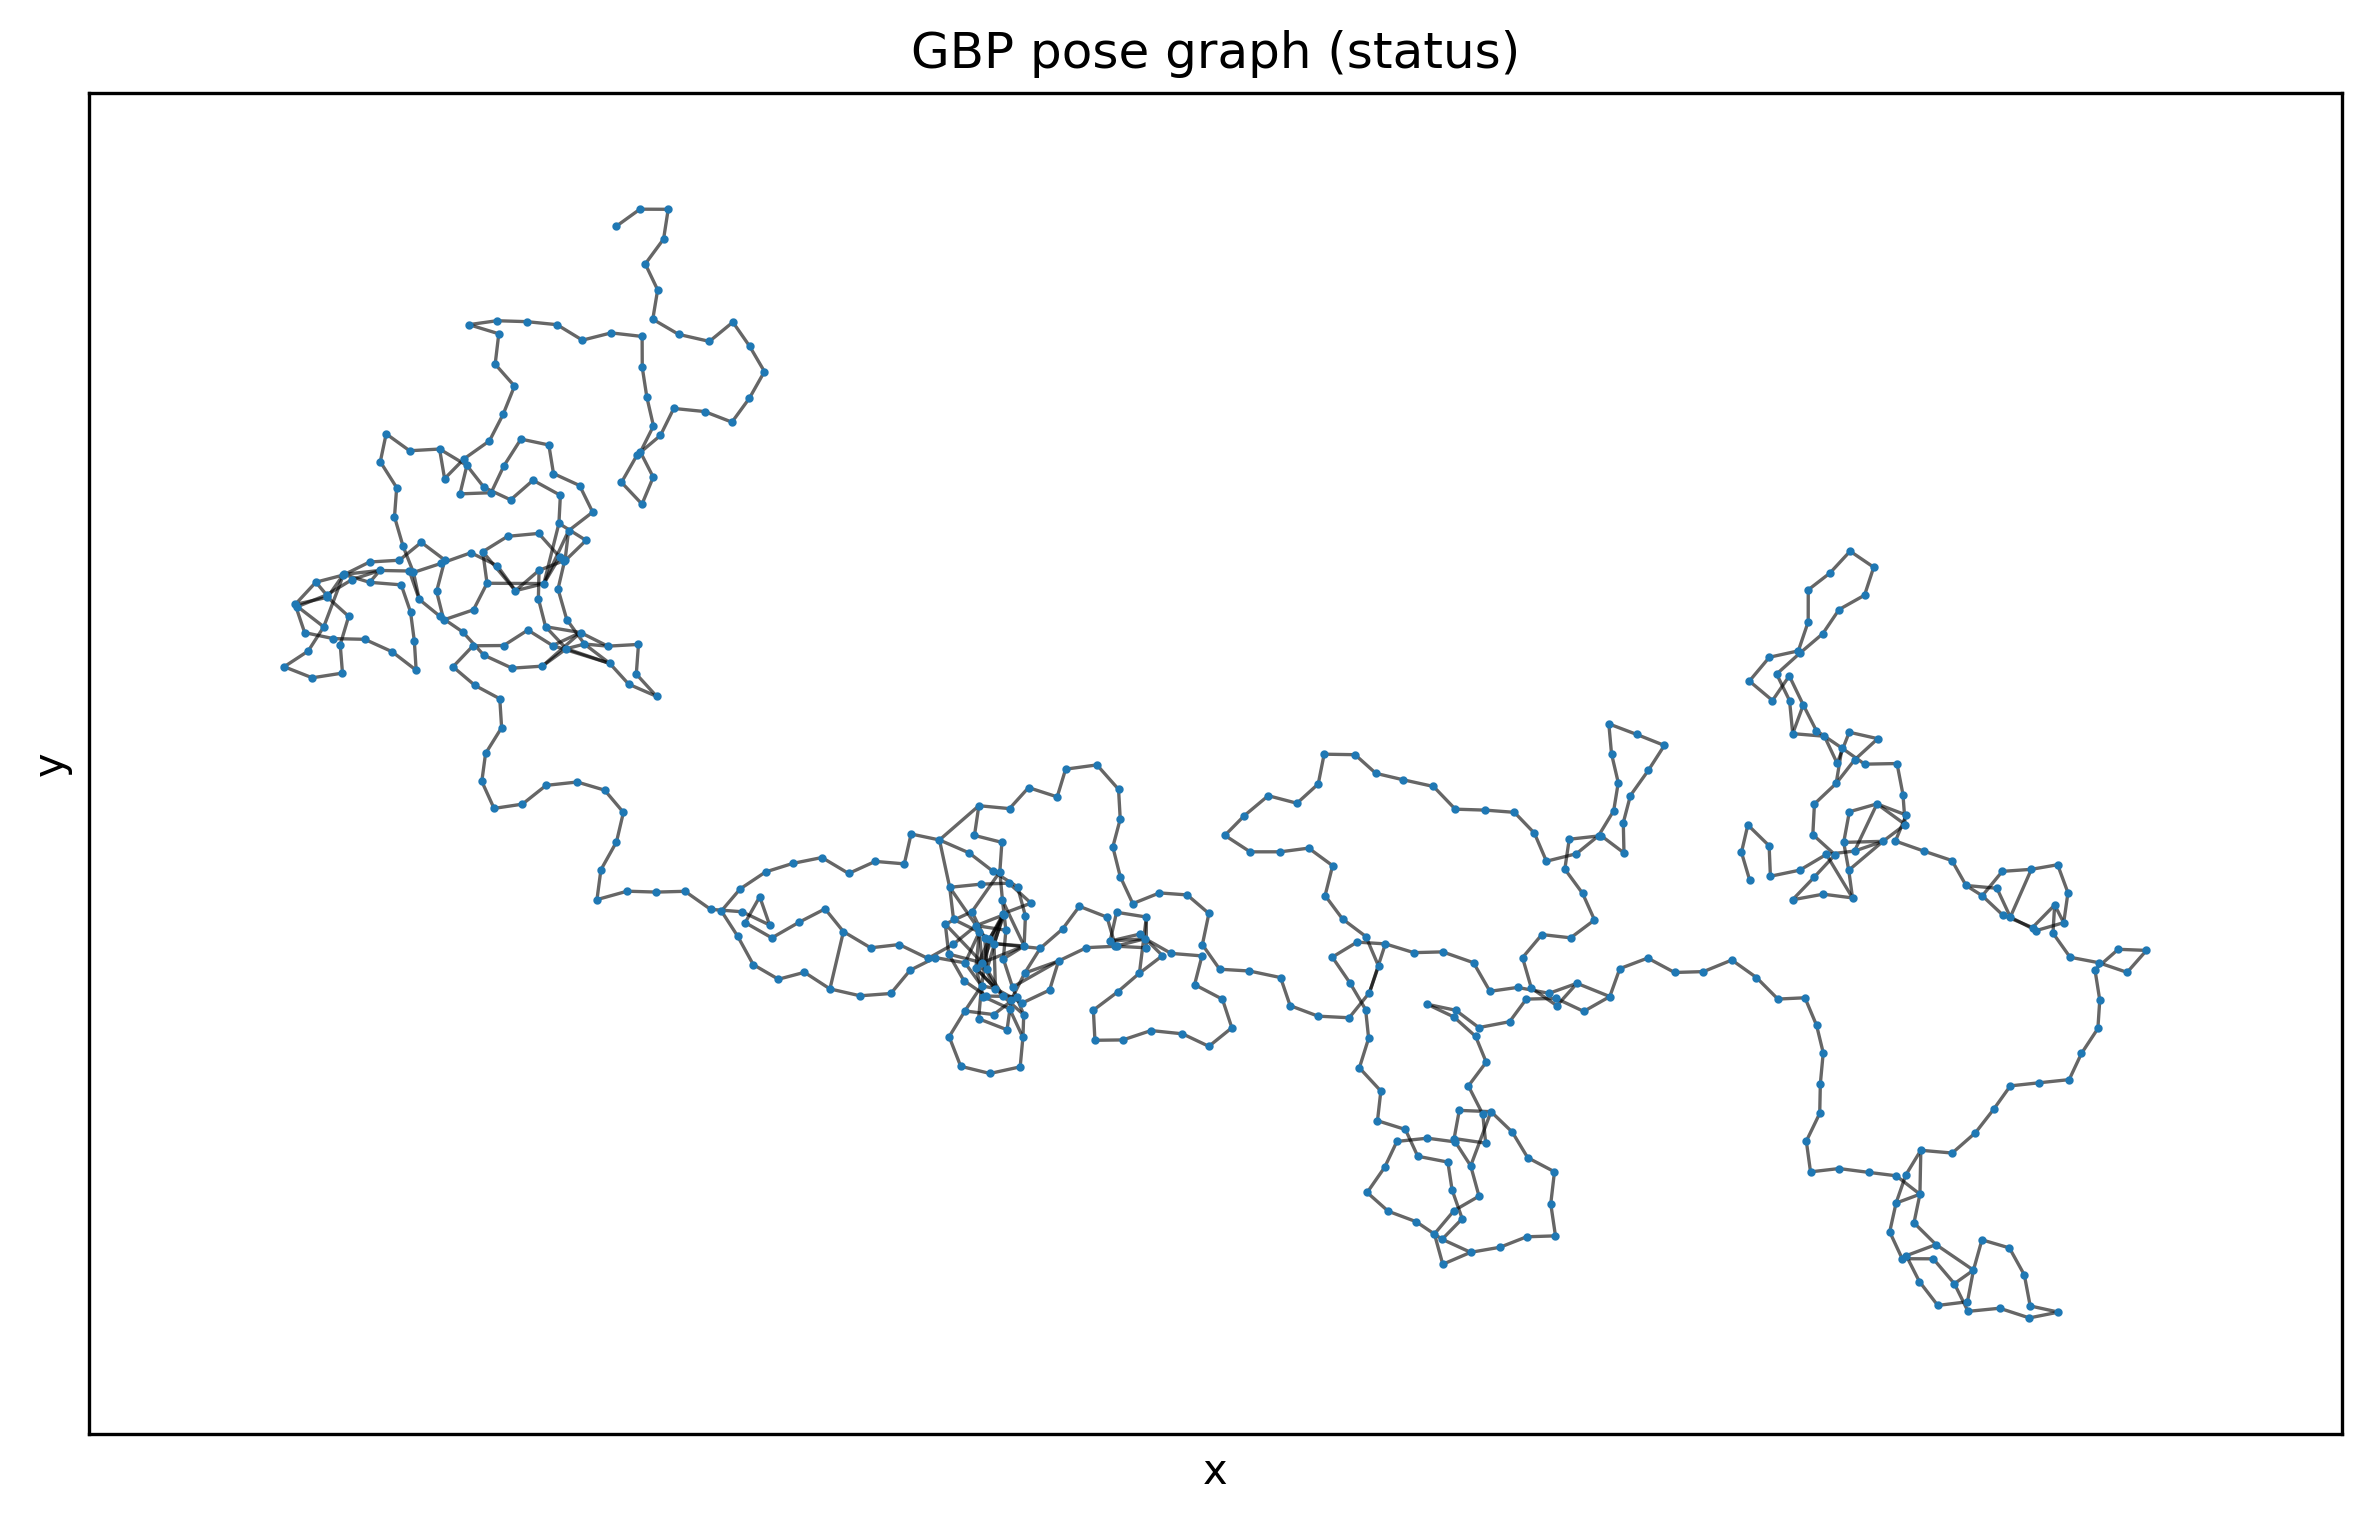

181

In [7]:
from collections import deque, defaultdict
%config InlineBackend.figure_format = 'retina'
plot_gbp_graph_xy(gbp_graph, edges, use="status", s=1, figsize=(8, 6), dpi=150)
diameter = graph_diameter(nodes, edges)
diameter

In [5]:
"""
gtsam_se2_benchmark_lm.py

Purpose
-------
Pure GTSAM benchmark for nonlinear SE(2) pose-graph:
- Use GTSAM's Pose2 / BetweenFactorPose2 / PriorFactorPose2
- Build one full graph (prior + odom + loop closures)
- Solve once with Levenberg-Marquardt (batch, one-shot)
- Report build time + solve time + basic diagnostics

Notes
-----
1) This is NOT using your GBP classes at all.
2) Measurements are SE(2) relative motions z_ij = (dx_local, dy_local, dtheta)
   which matches GTSAM Pose2 "between" convention.
3) Noise injection is done once, deterministically by seed, at graph construction.
4) Anchor: strong prior at node 0, plus optionally additional priors controlled by prior_prop.
   (Matches your generator's "prior edges to virtual prior".)

Run
---
python gtsam_se2_benchmark_lm.py
"""

import time
import numpy as np
import gtsam
from gtsam import symbol


# -----------------------
# Utilities
# -----------------------
def wrap_angle(a: float) -> float:
    return float(np.arctan2(np.sin(a), np.cos(a)))


def sigma_vec(s, theta_ratio=0.01) -> np.ndarray:
    v = np.array(s, dtype=float).ravel()
    if v.size == 1:
        s0 = float(v.item())
        return np.array([s0, s0, s0 * theta_ratio], dtype=float)
    if v.size != 3:
        raise ValueError("sigma must be scalar or length-3 [sx, sy, sth]")
    return v.astype(float)


def relpose_SE2(pose_i, pose_j):
    """z_ij = [dx_local, dy_local, dtheta], defined in i's coordinate frame."""
    xi, yi, thi = pose_i
    xj, yj, thj = pose_j
    c, s = np.cos(thi), np.sin(thi)
    RT = np.array([[ c, s],
                    [-s, c]])    # R(thi)^T
    dp = np.array([xj - xi, yj - yi])
    trans_local = RT @ dp
    dth = wrap_angle(thj - thi)
    return np.array([trans_local[0], trans_local[1], dth], dtype=float)

def compose_SE2(pose_i, z_ij):
    """Given local measurement z_ij, propagate from pose_i to pose_j."""
    xi, yi, thi = pose_i
    dx, dy, dth = z_ij
    c, s = np.cos(thi), np.sin(thi)
    t_global = np.array([c*dx - s*dy, s*dx + c*dy])
    xj = xi + t_global[0]
    yj = yi + t_global[1]
    thj = wrap_angle(thi + dth)
    return np.array([xj, yj, thj], dtype=float)


# -----------------------
# SLAM-like generator (clean GT + clean relative z on edges)
# -----------------------

def make_slam_like_graph(
    N=100, step_size=25, loop_prob=0.05, loop_radius=50, prior_prop=0.0, seed=None
):
    if seed is None:
        rng = np.random.default_rng()
    else:
        rng = np.random.default_rng(seed)
    # --- helpers ---
    def wrap_angle(a):
        # (-pi, pi]
        return np.arctan2(np.sin(a), np.cos(a))

    def relpose_SE2(pose_i, pose_j):
        """ Return z_ij = [dx_local, dy_local, dtheta] where 'local' is frame of i """
        xi, yi, thi = pose_i
        xj, yj, thj = pose_j
        Ri = np.array([[np.cos(thi), -np.sin(thi)],
                       [np.sin(thi),  np.cos(thi)]])
        dp = np.array([xj - xi, yj - yi])
        trans_local = Ri.T @ dp
        dth = wrap_angle(thj - thi)
        return np.array([trans_local[0], trans_local[1], dth], dtype=float)

    # --- SE(2) trajectory (smooth heading) ---
    poses = []
    x, y, th = 0.0, 0.0, 0.0
    poses.append((x, y, th))

    TURN_STD = 1  # rad, per step (tune smaller/larger as needed)
    for _ in range(1, int(N)):
        dth = rng.normal(0.0, TURN_STD)
        th = wrap_angle(th + dth)
        x += float(step_size) * np.cos(th)
        y += float(step_size) * np.sin(th)
        poses.append((x, y, th))

    # --- nodes (dim:3); visualization uses x,y ---
    nodes = []
    for i, (px, py, pth) in enumerate(poses):
        nodes.append({
            "data": {"id": f"{i}", "layer": 0, "dim": 3, "theta": float(pth), "num_base": 1},
            "position": {"x": float(px), "y": float(py)}  # for plotting only
        })

    # --- sequential odometry edges; attach measurement z_ij (local frame) ---
    edges = []
    for i in range(int(N) - 1):
        z_ij = relpose_SE2(poses[i], poses[i+1])
        edges.append({
            "data": {"source": f"{i}", "target": f"{i+1}", "kind": "odom", "z": z_ij.tolist()}
        })

    # --- loop-closure edges (proximity-triggered); also attach SE(2) measurements ---
    for i in range(int(N)):
        xi, yi, _ = poses[i]
        for j in range(i + 5, int(N)):  # consider loop closures only when gap >= 5 steps
            if rng.random() < float(loop_prob):
                xj, yj, _ = poses[j]
                if np.hypot(xi - xj, yi - yj) < float(loop_radius):
                    z_ij = relpose_SE2(poses[i], poses[j])
                    edges.append({
                        "data": {"source": f"{i}", "target": f"{j}", "kind": "loop", "z": z_ij.tolist()}
                    })

    # --- strong priors (anchors, etc.); still connect to the virtual "prior" ---
    if prior_prop <= 0.0:
        strong_ids = {}
    elif prior_prop >= 1.0:
        strong_ids = set(range(1,N))
    else:
        k = int(np.floor(prior_prop * N))
        strong_ids = set(rng.choice(np.arange(1, N), size=k, replace=False).tolist())


    for i in strong_ids:
        edges.append({"data": {"source": f"{i}", "target": "prior", "kind": "prior"}})

    return np.array(poses), edges


def make_graph_with_loop_spans(
    N=200,
    layout="line",          # "line" | "circle" | "random_walk"
    step=1.0,
    loop_spans_small=(3, 10),
    loop_spans_large=(60, 160),
    n_small=0,
    n_large=0,
    prior_prop=0.0,         # NEW: fraction of nodes (excluding 0) connected to "prior"
    seed=0,
):
    rng = np.random.default_rng(seed)

    def wrap_angle(a):
        return np.arctan2(np.sin(a), np.cos(a))

    def relpose_SE2(pose_i, pose_j):
        """z_ij = [dx_local, dy_local, dtheta], local frame is i"""
        xi, yi, thi = pose_i
        xj, yj, thj = pose_j
        Ri = np.array([[np.cos(thi), -np.sin(thi)],
                       [np.sin(thi),  np.cos(thi)]], dtype=float)
        dp = np.array([xj - xi, yj - yi], dtype=float)
        trans_local = Ri.T @ dp
        dth = wrap_angle(thj - thi)
        return np.array([trans_local[0], trans_local[1], dth], dtype=float)

    # --------- poses (GT) ----------
    poses = []
    if layout == "line":
        x = 0.0; y = 0.0; th = 0.0
        poses.append((x, y, th))
        for _ in range(1, N):
            x += step
            poses.append((x, y, th))

    elif layout == "circle":
        R = step * N / (2*np.pi)
        ang = np.linspace(0, 2*np.pi, N, endpoint=False)
        for a in ang:
            x = R * np.cos(a)
            y = R * np.sin(a)
            th = wrap_angle(a + np.pi/2)
            poses.append((float(x), float(y), float(th)))

    elif layout == "random_walk":
        x = 0.0; y = 0.0; th = 0.0
        poses.append((x, y, th))
        for _ in range(1, N):
            dth = rng.normal(0.0, 0.2)
            th = wrap_angle(th + dth)
            x += step * np.cos(th)
            y += step * np.sin(th)
            poses.append((float(x), float(y), float(th)))
    else:
        raise ValueError("layout must be line/circle/random_walk")

    # --------- nodes ----------
    nodes = []
    for i, (px, py, pth) in enumerate(poses):
        nodes.append({
            "data": {"id": f"{i}", "layer": 0, "dim": 3, "theta": float(pth), "num_base": 1},
            "position": {"x": float(px), "y": float(py)}
        })

    edges = []

    # --------- odom chain edges (binary, with z) ----------
    for i in range(N - 1):
        z_ij = relpose_SE2(poses[i], poses[i+1])
        edges.append({"data": {"source": f"{i}", "target": f"{i+1}", "kind": "odom", "z": z_ij.tolist()}})
    
    if layout == "circle":
        z_ij = relpose_SE2(poses[N-1], poses[0])
        edges.append({"data": {"source": f"{N-1}", "target": f"0", "kind": "odom", "z": z_ij.tolist()}})

    # --------- loop edges with controlled spans (binary, with z) ----------
    def add_loops(n_add, span_lo, span_hi, kind="loop"):
        if n_add <= 0:
            return
        span_lo = int(span_lo); span_hi = int(span_hi)
        assert 1 <= span_lo <= span_hi

        added = set()
        max_try = 50 * n_add
        t = 0
        while len(added) < n_add and t < max_try:
            t += 1
            span = int(rng.integers(span_lo, span_hi + 1))
            i = int(rng.integers(0, N - span))
            j = i + span
            key = (i, j)
            if key in added:
                continue
            added.add(key)
            z_ij = relpose_SE2(poses[i], poses[j])
            edges.append({"data": {"source": f"{i}", "target": f"{j}", "kind": kind, "z": z_ij.tolist()}})

    add_loops(n_small, loop_spans_small[0], loop_spans_small[1], kind="loop")
    add_loops(n_large, loop_spans_large[0], loop_spans_large[1], kind="loop")

    # --------- priors: connect some nodes to virtual "prior" ----------
    if prior_prop <= 0.0:
        strong_ids = set()
    elif prior_prop >= 1.0:
        strong_ids = set(range(1, N))   # exclude 0 (already anchored strongly in build_noisy_pose_graph)
    else:
        k = int(np.floor(float(prior_prop) * N))
        k = max(0, min(k, N - 1))
        strong_ids = set(rng.choice(np.arange(1, N), size=k, replace=False).tolist())

    for i in strong_ids:
        edges.append({"data": {"source": f"{i}", "target": "prior", "kind": "prior"}})

    return np.array(poses), edges


# -----------------------
# Build GTSAM Pose2 graph + initial
# -----------------------
import numpy as np
import gtsam
from gtsam import symbol

def build_gtsam_pose2_graph(
    GT_poses,  # (N,3) used ONLY to generate clean measurements / prior means
    edges,     # list of (i, j, kind, z_clean)  z_clean = [dx,dy,dth] in i-local
    prior_sigma=1.0,
    odom_sigma=1.0,
    loop_sigma=1.0,
    theta_ratio=0.01,
    seed=2001,
    add_measurement_noise=True,
    add_prior_noise=True,
    anchor_strong=True,
    anchor_sigmas=(1e-3, 1e-3, 1e-5),
):
    rng = np.random.default_rng(seed)
    N = int(GT_poses.shape[0])

    # noise models (sigmas)
    prior_sig = sigma_vec(prior_sigma, theta_ratio)  # (3,)
    odom_sig  = sigma_vec(odom_sigma, theta_ratio)   # (3,)
    loop_sig  = sigma_vec(loop_sigma, theta_ratio)   # (3,)

    prior_model = gtsam.noiseModel.Diagonal.Sigmas(gtsam.Point3(*prior_sig))
    odom_model  = gtsam.noiseModel.Diagonal.Sigmas(gtsam.Point3(*odom_sig))
    loop_model  = gtsam.noiseModel.Diagonal.Sigmas(gtsam.Point3(*loop_sig))

    graph = gtsam.NonlinearFactorGraph()
    initial = gtsam.Values()

    def key(i: int):
        return symbol("x", int(i))

    # ------------------------------------------------------------
    # Store the EXACT noisy measurements used by factors
    # so init can reuse them (no GT init, deterministic).
    # ------------------------------------------------------------
    strong_prior_meas = {}   # i -> noisy Pose (x,y,th) used in PriorFactorPose2
    odom_meas = {}           # (i,i+1) -> noisy z_ij used in BetweenFactorPose2 (odom edges only)


    a = np.array(anchor_sigmas, dtype=float).ravel()
    if a.size != 3:
        raise ValueError("anchor_sigmas must be length-3")
    anchor_model = gtsam.noiseModel.Diagonal.Sigmas(
        gtsam.Point3(float(a[0]), float(a[1]), float(a[2]))
    )

    z0 = GT_poses[0].copy()
    graph.add(gtsam.PriorFactorPose2(
        key(0),
        gtsam.Pose2(float(z0[0]), float(z0[1]), float(z0[2])),
        anchor_model
    ))


    for e in edges:
        src = e["data"]["source"]
        dst = e["data"]["target"]

        if dst != "prior":
            i, j = int(src), int(dst)

            # Ground-truth relative pose
            z = np.array(e["data"]["z"], dtype=float).ravel()

            kind = e["data"].get("kind", "between")

            if kind == "loop":
                n = rng.normal(0.0, loop_sig, size=3)
                model = loop_model
            else:
                n = rng.normal(0.0, odom_sig, size=3)
                model = odom_model

            z_noisy = z.copy()
            z_noisy[:2] += n[:2]
            z_noisy[2] = wrap_angle(z_noisy[2] + n[2])

            # store odom for chaining ONLY if it's sequential odom edge (i,i+1)
            if kind == "odom" and (j == i + 1):
                odom_meas[(i, j)] = z_noisy.copy()

            graph.add(gtsam.BetweenFactorPose2(
                key(i), key(j),
                gtsam.Pose2(float(z_noisy[0]), float(z_noisy[1]), float(z_noisy[2])),
                model
            ))

        else:
            i = int(src)
            z = GT_poses[i].copy()
            if add_prior_noise:
                n = rng.normal(0.0, prior_sig, size=3)
                z[:2] += n[:2]
                z[2] = wrap_angle(z[2] + n[2])

            strong_prior_meas[i] = z.copy()

            graph.add(gtsam.PriorFactorPose2(
                key(i),
                gtsam.Pose2(float(z[0]), float(z[1]), float(z[2])),
                prior_model
            ))

    # ------------------------------------------------------------
    # (D) INITIALIZATION per your requirement:
    # start from (0,0,0), propagate with odom ⊕,
    # when hit a strong prior node, hard reset to that prior mean measurement.
    # ------------------------------------------------------------
    mu = np.zeros((N, 3), dtype=float)
    mu[0] = np.array([0.0, 0.0, 0.0], dtype=float)

    for i in range(N - 1):
        if (i, i + 1) in odom_meas:
            mu[i + 1] = compose_SE2(mu[i], odom_meas[(i, i + 1)])
        else:
            print(f"Missing odom between {i} and {i+1}")
            # missing odom: hold last pose (still not GT)
            mu[i + 1] = mu[i].copy()

        # reset at strong prior node
        if (i + 1) in strong_prior_meas:
            mu[i + 1] = strong_prior_meas[i + 1].copy()

    for i in range(N):
        initial.insert(key(i), gtsam.Pose2(float(mu[i, 0]), float(mu[i, 1]), float(mu[i, 2])))

    
    return graph, initial



# -----------------------
# Solve once with LM (batch)
# -----------------------
def solve_lm_once(graph, initial, max_iters=100, rel_error_tol=1e-9, abs_error_tol=1e-9, lambda_initial=1e-3):
    params = gtsam.LevenbergMarquardtParams()
    #params = gtsam.GaussNewtonParams()
    params.setVerbosityLM("SILENT")  # for timing
    #params.setVerbosityLM("SUMMARY")
    params.setMaxIterations(int(max_iters))
    params.setRelativeErrorTol(float(rel_error_tol))
    params.setAbsoluteErrorTol(float(abs_error_tol))
    params.setlambdaInitial(float(lambda_initial))

    optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial, params)
    #optimizer = gtsam.GaussNewtonOptimizer(graph, initial, params)

    t0 = time.perf_counter()
    result = optimizer.optimize()
    t1 = time.perf_counter()
    return result, (t1 - t0)


def batch_benchmark(
    N=512,
    step_size=25,
    loop_prob=0.05,
    loop_radius=50,
    prior_prop=0.02,
    prior_sigma=1.0,
    odom_sigma=1.0,
    loop_sigma=1.0,
    theta_ratio=0.01,
    seed=2001,
    runs=5,
    warmup=1,
):
    # generate GT + clean graph topology
    GT, edges = make_slam_like_graph(
        N=N,
        step_size=step_size,
        loop_prob=loop_prob,
        loop_radius=loop_radius,
        prior_prop=prior_prop,
        seed=seed,
    )

    GT, edges = make_graph_with_loop_spans(N=N, step=step_size, layout="circle", loop_spans_small=(3, 10), 
            loop_spans_large=(int(N//3), int(N//2)), n_small=0, n_large=10, prior_prop=prior_prop, seed=seed)

    # Build once (build time matters too, so measure separately if you want)
    t_build0 = time.perf_counter()
    graph, initial = build_gtsam_pose2_graph(
        GT, edges,
        prior_sigma=prior_sigma,
        odom_sigma=odom_sigma,
        loop_sigma=loop_sigma,
        theta_ratio=theta_ratio,
        seed=seed,
        add_measurement_noise=True,
        add_prior_noise=True,
        anchor_strong=True,
    )
    t_build1 = time.perf_counter()

    # Warmup solve(s) to avoid first-call overhead in timing (allocations, etc.)
    for _ in range(max(0, int(warmup))):
        _ = solve_lm_once(graph, initial, max_iters=100)[0]

    # Timed runs
    times = []
    last_result = None
    for _ in range(int(runs)):
        last_result, dt = solve_lm_once(graph, initial, max_iters=200)
        times.append(dt)

    times = np.array(times, dtype=float)

    # Basic diagnostics: final error
    final_error = graph.error(last_result)

    print("=== GTSAM Pose2 Batch LM Benchmark ===")
    print(f"sigmas: prior={prior_sigma}, odom={odom_sigma}, loop={loop_sigma}, theta_ratio={theta_ratio}")
    print(f"build_time: {(t_build1 - t_build0)*1000:.3f} ms")
    print(f"solve_time over {runs} runs (after warmup={warmup}):")
    print(f"  mean = {times.mean()*1000:.3f} ms")
    print(f"  std  = {times.std()*1000:.3f} ms")
    print(f"  min  = {times.min()*1000:.3f} ms")
    print(f"  max  = {times.max()*1000:.3f} ms")
    print(f"final_graph_error = {final_error:.6g}", f"final_SE = {se2_squared_sum(last_result, gt_array_to_values(GT)):.6g}")

    lm_iter_timing_print(graph, initial, gt_array_to_values(GT), max_iters=200)
    return {
        "build_s": float(t_build1 - t_build0),
        "solve_s_mean": float(times.mean()),
        "solve_s_std": float(times.std()),
        "solve_s_min": float(times.min()),
        "solve_s_max": float(times.max()),
        "final_error": float(final_error),
        "edges": int(len(edges)),
        "GT": GT,
        "result": last_result,
        "initial": initial,
        "graph": graph,
    }


import time
import numpy as np
import gtsam
from gtsam import symbol

def se2_squared_sum(values: gtsam.Values, gt_values: gtsam.Values) -> float:
    sse = 0.0
    for key in values.keys():
        if not gt_values.exists(key):
            continue
        X  = values.atPose2(key)
        Xg = gt_values.atPose2(key)

        between = Xg.between(X)
        e = np.asarray(gtsam.Pose2.Logmap(between)).reshape(-1)
        sse += float(e @ e)
    return sse


def gt_array_to_values(GT: np.ndarray) -> gtsam.Values:
    gt_values = gtsam.Values()
    N = int(GT.shape[0])
    for i in range(N):
        gt_values.insert(
            symbol("x", i),
            gtsam.Pose2(float(GT[i,0]), float(GT[i,1]), float(GT[i,2]))
        )
    return gt_values


def lm_iter_timing_print(
    graph,
    initial,
    gt_values,
    max_iters=20,
    lambda_initial=1e-3,
    abs_tol=1e-9,          # absolute error improvement threshold
    rel_tol=1e-9,          # relative error improvement threshold
    stall_iters=3,         # require k consecutive "small improvements" before stopping
    min_iters=1,           # force at least this many iterations
    print_every=1,
):
    """
    Run LM manually with per-iteration timing and early stopping based on error improvement.

    Stopping rule (after min_iters):
      let e_prev, e_now
      improvement = e_prev - e_now

      stop if improvement <= abs_tol  OR  improvement/|e_prev| <= rel_tol
      for `stall_iters` consecutive iterations.

    Notes
    -----
    - This is the cleanest Python-side way to mimic LM termination when verbosity is not available.
    - If an iteration increases error (rejected step / damping behavior), improvement becomes negative;
      that counts as "stall" and accelerates termination unless you change the logic below.
    """

    params = gtsam.GaussNewtonParams()
    params.setVerbosity("SILENT")          # 可选：SILENT / ERROR / TERMINATION / etc.
    params.setMaxIterations(int(max_iters))

    # 如果你想尽量不让它内部 early stop，就把阈值设得极小
    params.setRelativeErrorTol(1e-20)
    params.setAbsoluteErrorTol(1e-20)

    opt = gtsam.GaussNewtonOptimizer(graph, initial, params)
    print("init error",opt.error(), "init SE=", se2_squared_sum(opt.values(), gt_values))  # 初始化内部状态

    ts = []
    errors = []

    e_prev = float(opt.error())
    errors.append(e_prev)

    stall_count = 0

    for k in range(max_iters):
        t0 = time.perf_counter()
        opt.iterate()  # 1 iter = relinearize + linear solve + retract (+ lambda update)
        t1 = time.perf_counter()

        dt_ms = (t1 - t0) * 1000.0
        ts.append(dt_ms)

        e_now = float(opt.error())
        errors.append(e_now)

        improvement = e_prev - e_now
        
        SE = se2_squared_sum(opt.values(), gt_values)
        rel_impr = improvement / (abs(e_prev) + 1e-30)

        if (k % print_every) == 0:
            print(
                f"[TIMING] iter {k:03d}: {dt_ms:8.3f} ms | "
                f"error={e_now:.6e} | SE={SE:.5e} | rel_dE={rel_impr:.5e}"
            )

        # --- early stop logic ---
        if (k + 1) >= min_iters:
            # define "stalled" as very small improvement (or worse)
            stalled = (improvement <= abs_tol) or (rel_impr <= rel_tol)
            if stalled:
                stall_count += 1
            else:
                stall_count = 0

            if stall_count >= stall_iters:
                print(
                    f"[STOP] stalled for {stall_iters} iters "
                    f"(abs_tol={abs_tol:.1e}, rel_tol={rel_tol:.1e}) at iter {k:03d}."
                )
                break

        e_prev = e_now

    return opt.values(), np.array(ts, dtype=float), np.array(errors, dtype=float)


if __name__ == "__main__":
    # ---- your config (copied from your message) ----
    stats = batch_benchmark(
        N=512,
        step_size=25,
        loop_prob=0.05,
        loop_radius=50,
        prior_prop=0.02,
        prior_sigma=1,
        odom_sigma=1,
        loop_sigma=10,
        theta_ratio=0.01,   # same as your THETA_RATIO
        seed=201,
        runs=10,
        warmup=1,
    )



=== GTSAM Pose2 Batch LM Benchmark ===
sigmas: prior=1, odom=1, loop=10, theta_ratio=0.01
build_time: 11.506 ms
solve_time over 10 runs (after warmup=1):
  mean = 63.176 ms
  std  = 3.382 ms
  min  = 58.711 ms
  max  = 70.662 ms
final_graph_error = 34.9939 final_SE = 13234.6
init error 2087398943493.5398 init SE= 10570559.196128793
[TIMING] iter 000:    2.566 ms | error=3.358145e+06 | SE=5.32038e+07 | rel_dE=9.99998e-01
[TIMING] iter 001:    2.143 ms | error=8.771933e+05 | SE=1.33782e+07 | rel_dE=7.38786e-01
[TIMING] iter 002:    2.032 ms | error=4.824290e+05 | SE=4.76257e+06 | rel_dE=4.50031e-01
[TIMING] iter 003:    1.897 ms | error=8.151566e+04 | SE=3.56861e+06 | rel_dE=8.31031e-01
[TIMING] iter 004:    2.077 ms | error=5.876676e+03 | SE=3.45690e+05 | rel_dE=9.27907e-01
[TIMING] iter 005:    1.840 ms | error=4.579700e+01 | SE=1.44251e+04 | rel_dE=9.92207e-01
[TIMING] iter 006:    1.972 ms | error=3.502316e+01 | SE=1.32137e+04 | rel_dE=2.35252e-01
[TIMING] iter 007:    1.955 ms | err

In [35]:
full = 0
for i, var  in enumerate(gbp_graph.var_nodes):
    a = [var.GT.translation()[0], var.GT.translation()[1], var.GT.angle()]
    full += np.linalg.norm(stats["GT"][i] - a)

print(full)


import numpy as np
import gtsam

def values_to_array_pose2(values: gtsam.Values, N: int) -> np.ndarray:
    arr = np.zeros((N, 3), dtype=float)

    for key in values.keys():
        s = gtsam.Symbol(key)      # <-- 关键：解码 key
        if s.chr() != ord('x'):    # chr() returns ASCII int
            continue

        idx = int(s.index())
        pose = values.atPose2(key)

        arr[idx, 0] = pose.x()
        arr[idx, 1] = pose.y()
        arr[idx, 2] = pose.theta()

    return arr

full = 0
init = values_to_array_pose2(stats["initial"], N=N)
for i, var  in enumerate(gbp_graph.var_nodes):
    a = [var.status.translation()[0], var.status.translation()[1], var.status.angle()]
    full += np.linalg.norm(init[i] - a)

print(full)

1.8735013540549517e-16
1.1473218026986128e-10


In [36]:
N=512
step=25
prob=0.05
radius=50 
prior_prop=0.02
prior_sigma=1
odom_sigma=1
loop_sigma=10
seed = 201

from utils.graphs import build_noisy_pose_graph, make_slam_like_graph
nodes, edges = make_slam_like_graph(N, step, prob, radius, prior_prop, seed=seed)
"""
nodes, edges = make_graph_with_loop_spans(N=N, step=25, layout="circle", loop_spans_small=(3, 10), 
            loop_spans_large=(int(N//3), int(N//2)), n_small=0, n_large=10, prior_prop=prior_prop, seed=seed)
"""



init = values_to_array_pose2(stats["initial"], N=N)
# construct GBP graph
gbp_graph = build_noisy_pose_graph(nodes, edges, prior_sigma=prior_sigma, odom_sigma=odom_sigma, 
            loop_sigma=loop_sigma, seed=seed)

full = 0
for i, var  in enumerate(gbp_graph.var_nodes):
    a = [var.status.translation()[0], var.status.translation()[1], var.status.angle()]
    full += np.linalg.norm(init[i] - a)

full

print(gbp_graph.SE())
print(se2_squared_sum(stats["initial"], gt_array_to_values(stats["GT"])))

5010.147249710799
5010.045538623021


74074.75278574196